In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [19]:
#Creating a pivot table that shows the no.of job postings by month in Singapore
sg_jobs=df[df['job_country']=='Singapore']
sg_jobs['job_posted_month']=sg_jobs['job_posted_date'].dt.strftime('%B')
pivot_df= sg_jobs.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
pivot_df.reset_index(inplace=True)
pivot_df['month_no']=pd.to_datetime(pivot_df['job_posted_month'], format='%B').dt.month
pivot_df.sort_values('month_no', inplace=True)
pivot_df.drop(columns='month_no',inplace=True)
pivot_df.set_index('job_posted_month',inplace=True)
pivot_df


C:\Users\dell\AppData\Local\Temp\ipykernel_9028\2205238302.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sg_jobs['job_posted_month']=sg_jobs['job_posted_date'].dt.strftime('%B')


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,156,30,639,604,372,68,111,110,108,153
February,114,10,392,400,225,53,80,67,71,87
March,146,30,538,462,284,87,118,84,58,185
April,259,77,521,486,332,75,103,87,69,202
May,115,25,462,408,274,35,97,61,56,79
June,150,22,560,513,319,60,89,105,70,77
July,165,28,662,524,282,59,121,96,66,138
August,193,42,625,593,334,79,96,100,75,139
September,140,28,348,302,170,54,53,54,40,100


In [16]:
#loading a similar dataframe that deals with software jobs
sw_jobs=pd.read_csv('https://lukeb.co/software_csv')
sw_jobs

,job_posted_month,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,January,13619,9827,5108,4348
1,February,11456,9116,7298,4284
2,March,11102,8178,5814,4159
3,April,14037,9209,7232,4220
4,May,12126,8864,6718,4980
5,June,12003,8065,5902,4781
6,July,11914,8061,6839,4344
7,August,11571,8191,7413,4104
8,September,14016,8447,6139,4094
9,October,11419,8476,5026,4389


In [17]:
#setting the job month as the index for the new dataframe
sw_jobs.set_index('job_posted_month', inplace=True)


In [ ]:
#Merging the 2 dataframes using .merge() 
new_df= pivot_df.merge(sw_jobs, on='job_posted_month')
new_df

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,156,30,639,604,372,68,111,110,108,153,13619,9827,5108,4348
February,114,10,392,400,225,53,80,67,71,87,11456,9116,7298,4284
March,146,30,538,462,284,87,118,84,58,185,11102,8178,5814,4159
April,259,77,521,486,332,75,103,87,69,202,14037,9209,7232,4220
May,115,25,462,408,274,35,97,61,56,79,12126,8864,6718,4980
June,150,22,560,513,319,60,89,105,70,77,12003,8065,5902,4781
July,165,28,662,524,282,59,121,96,66,138,11914,8061,6839,4344
August,193,42,625,593,334,79,96,100,75,139,11571,8191,7413,4104
September,140,28,348,302,170,54,53,54,40,100,14016,8447,6139,4094


In [ ]:
#Finding the top 5 mosted posted jobs in the merged dataframe
top_jobs=new_df.sum().sort_values(ascending=False).head().index
top_jobs


Index(['Front-End Developer', 'Back-End Developer', 'Full-Stack Developer',
       'UI/UX Designer', 'Data Analyst'],
      dtype='object')

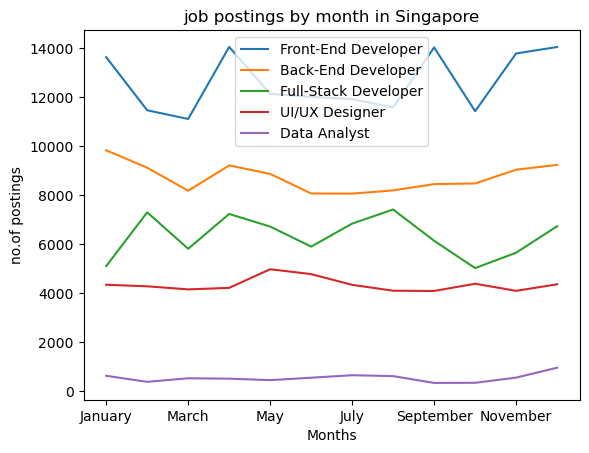

In [30]:
#plotting a graph that shows the monthly postings for the top jobs in Singapore
new_df[top_jobs].plot(kind='line')
plt.xlabel('Months')
plt.ylabel('no.of postings')
plt.title('job postings by month in Singapore')
plt.legend()
plt.show()